In [ ]:
### Compiling RunTimes from directory of CSV files
## may also want to do this later with parquets could make it more intesting but to start keep it simple stupud

from pathlib import Path
import pandas as pd
import numpy as np

def compile_runtimes(directory):
    """
    Compile all values from the 'RunTime' column across all CSV files.

    Parameters
    ----------
    directory : str or Path
        Directory containing CSV files.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame containing all runtime and ROI area values.

    n_files : int
        Number of CSV files that contained a 'RunTime' column.
    """
    runtimes = []
    RoiTypes = []
    roi_widths = []
    roi_heights = []
    n_files = 0

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)

        if "RunTime" in df.columns:
            runtimes.extend(df["RunTime"].dropna())
            n_files += 1


        if "RoiWidth" in df.columns:
            roi_widths.extend(df["RoiWidth"].dropna())
            n_files += 1

        if "RoiHeight" in df.columns:
            roi_heights.extend(df["RoiHeight"].dropna())
            n_files += 1
            
    results_df = pd.DataFrame({
        "RunTime": runtimes,
        "RoiWidth": roi_widths,
        "RoiHeight": roi_heights
    })
    return results_df, n_files
   

In [2]:
test_df = pd.read_csv("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/alexFixed/FixedAlex/merged/D20260827T002533_IFCB124_adc_only.csv")

In [4]:
print(test_df.head())

   trigger#  RoiNumber      PMTB    ADCtime    RunTime  InhibitTime  \
0         2          2  0.291404   9.800122   9.822793     0.072836   
1         3          3  0.495716  10.201508  10.223809     0.156220   
2         4          4  0.009540  10.376569  10.398993     0.240560   
3         5          5  0.732632  10.519897  10.541265     0.322752   
4         6          6  0.619248  10.660237  10.682552     0.406237   

   InhibitTimeDiff  VolumeAnalyzed  RoiType  RoiHeight  RoiWidth  RoiX  RoiY  
0         0.072836        0.040625        1        124       144   820   614  
1         0.083383        0.041948        1        124       152   788   814  
2         0.084340        0.042327        1         60        80   876   686  
3         0.082192        0.042577        1        124       152   788   750  
4         0.083485        0.042818        1        132       152   804   502  


In [8]:
results_df, n_files = compile_runtimes("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/SeaTrac/IOS2026/plusultra/merged")

In [10]:
results_df["RoiArea"]= results_df["RoiWidth"] * results_df["RoiHeight"]

In [17]:
filtered_df = results_df[results_df["RunTime"]<=1200]
filtered_df["MaxDimension"] = filtered_df[["RoiWidth", "RoiHeight"]].max(axis=1)

/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_2982/3054407293.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["MaxDimension"] = filtered_df[["RoiWidth", "RoiHeight"]].max(axis=1)


Text(0.5, 0, 'RunTime')

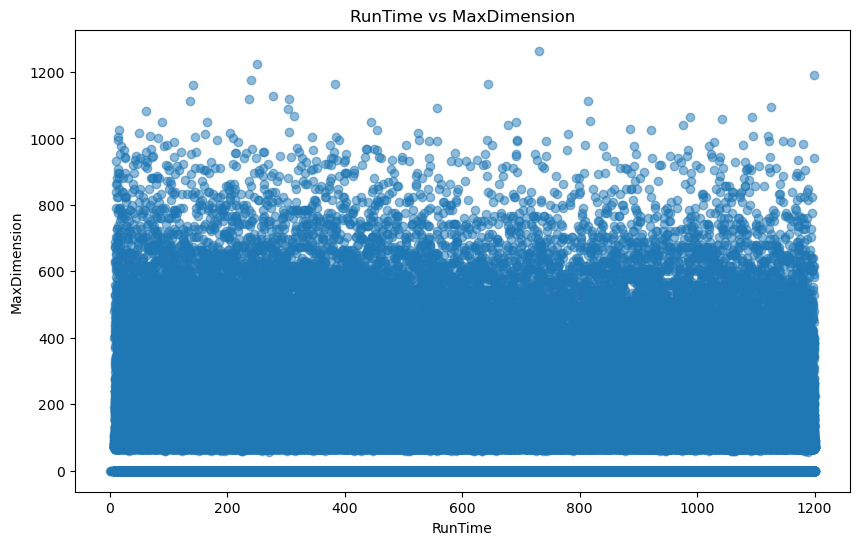

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(filtered_df["RunTime"], filtered_df["MaxDimension"], alpha=0.5)
plt.title("RunTime vs MaxDimension")
plt.ylabel("MaxDimension")
plt.xlabel("RunTime")


Text(0, 0.5, 'Frequency')

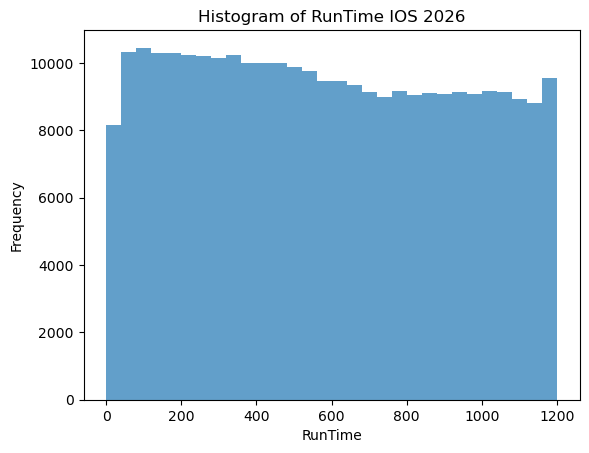

In [22]:
plt.hist(filtered_df["RunTime"], bins=30, alpha=0.7)
plt.title("Histogram of RunTime IOS 2026")
plt.xlabel("RunTime")
plt.ylabel("Frequency")

In [5]:
from pathlib import Path
import pandas as pd

def combine_csvs_with_filename(directory):
    """
    Combine all CSV files in a directory into one DataFrame.
    Adds a 'FileName' column containing the source filename.
    """
    dfs = []

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)
        df["FileName"] = file.name
        dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [6]:
master_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/alexFixed/FixedAlex/merged")

Text(0.5, 1.0, 'Distribution of RunTimes in Fixed Alex Culture')

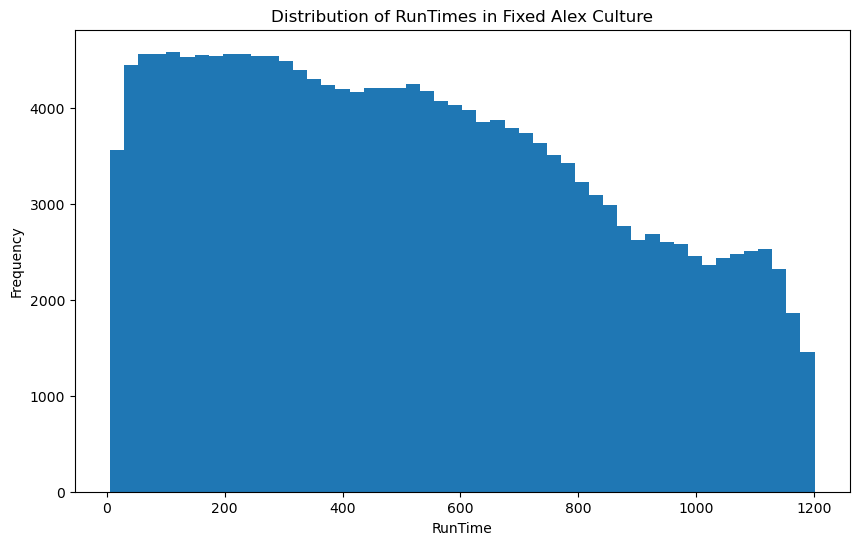

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(master_df["RunTime"], bins=50)
plt.xlabel("RunTime")
plt.ylabel("Frequency")
plt.title("Distribution of RunTimes in Fixed Alex Culture")